# Unveiling the Android App Market

### Oasis Infobyte Internship (OIBSIP)

**Domain:** Data Analytics

**Task Level:** Level 2

**Task:** Unveiling the Android App Market

**Submitted by:** **S Pandi Durai**

## 1. Introduction

The Google Play Store hosts millions of Android applications across various categories, serving users worldwide. Understanding trends in app categories, user ratings, installs, pricing, and reviews can provide valuable insights into the mobile application market.

In this project, Exploratory Data Analysis (EDA) is performed on the Google Play Store dataset to uncover patterns in app performance, popularity, pricing, and customer preferences. The analysis aims to transform raw application data into meaningful business insights that can support developers, businesses, and market analysts.

## 2. Import Required Libraries

The following libraries are imported for data manipulation, visualization, and exploratory data analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

## 3. Load the Dataset

The dataset is loaded into a Pandas DataFrame to begin the exploratory data analysis process.

In [3]:
df = pd.read_csv("dataset.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 4. Dataset Overview

Before performing any analysis, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, column names, and data types.

In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (10841, 13)

Column Names:
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Data Types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


## 5. Data Quality Assessment

Data quality assessment is an essential preprocessing step that helps identify missing values and duplicate records in the dataset. Detecting these issues ensures that the analysis is performed on clean and reliable data.

The following checks are performed:

- Missing values
- Duplicate records

In [5]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate Records: 483


## 6. Data Cleaning

Data cleaning is performed to improve the quality of the dataset before analysis. This process includes:

- Removing duplicate records
- Handling missing values
- Converting columns to appropriate data types
- Preparing the dataset for exploratory data analysis

In [6]:
print("Duplicate Records Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Records After:", df.duplicated().sum())

Duplicate Records Before: 483
Duplicate Records After: 0


### 6.2 Handling Missing Values

Missing values can affect statistical analysis and lead to inaccurate conclusions. Numerical and categorical columns require different imputation techniques.

- Numerical columns are filled using the **median**.
- Categorical columns are filled using the **mode**.

In [7]:
print("Missing Values Before:\n")
print(df.isnull().sum())

# Fill numerical column
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# Fill categorical columns
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])
df["Content Rating"] = df["Content Rating"].fillna(df["Content Rating"].mode()[0])
df["Current Ver"] = df["Current Ver"].fillna(df["Current Ver"].mode()[0])
df["Android Ver"] = df["Android Ver"].fillna(df["Android Ver"].mode()[0])

print("\nMissing Values After:\n")
print(df.isnull().sum())

Missing Values Before:

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing Values After:

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


### 6.3 Removing the Corrupted Record

The dataset contains one corrupted record where the values are shifted across multiple columns. This causes errors when converting columns such as **Reviews**, **Installs**, and **Price** to numeric data types.

The corrupted record is removed before further preprocessing.

In [12]:
# Display the corrupted row
df[df["App"] == "Life Made WI-Fi Touchscreen Photo Frame"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Everyone,"February 11, 2018",1.0.19,4.0 and up,4.1 and up


In [13]:
df = df[df["App"] != "Life Made WI-Fi Touchscreen Photo Frame"]

print(df.shape)

(10357, 13)


In [14]:
print("Shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (10357, 13)

Duplicate rows: 0

Missing values:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


### 6.4 Converting the Reviews Column

The **Reviews** column contains the total number of user reviews for each application. Although it represents numerical data, it is initially stored as text (`object` data type).

After removing the corrupted record, the column is converted to a numeric data type to enable statistical analysis and visualization.

In [15]:
print("Before Conversion:")
print(df["Reviews"].head())

# Convert Reviews to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"])

print("\nData Type:", df["Reviews"].dtype)

print("\nAfter Conversion:")
print(df["Reviews"].head())

Before Conversion:
0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object

Data Type: int64

After Conversion:
0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: int64


### 6.5 Converting the Installs Column

The **Installs** column indicates the approximate number of times an application has been installed. However, the values are stored as text and contain commas (`,`) and plus signs (`+`), which prevent numerical analysis.

These special characters are removed before converting the column into a numeric data type.

In [16]:
print("Before Conversion:")
print(df["Installs"].head())

# Remove commas and plus signs
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

# Convert to numeric
df["Installs"] = pd.to_numeric(df["Installs"])

print("\nData Type:", df["Installs"].dtype)

print("\nAfter Conversion:")
print(df["Installs"].head())

Before Conversion:
0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: object

Data Type: int64

After Conversion:
0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64


### 6.6 Converting the Price Column

The **Price** column represents the cost of paid applications. Since the values include the dollar symbol (`$`), they must be cleaned before converting the column into a numeric data type.

This conversion enables price-based statistical analysis and comparison between free and paid applications.

In [17]:
print("Before Conversion:")
print(df["Price"].head())

# Remove dollar sign
df["Price"] = df["Price"].str.replace("$", "", regex=False)

# Convert to numeric
df["Price"] = pd.to_numeric(df["Price"])

print("\nData Type:", df["Price"].dtype)

print("\nAfter Conversion:")
print(df["Price"].head())

Before Conversion:
0    0
1    0
2    0
3    0
4    0
Name: Price, dtype: object

Data Type: float64

After Conversion:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


### 6.7 Cleaning the Size Column

The **Size** column contains application sizes in different formats, including megabytes (**M**), kilobytes (**k**), and the value **"Varies with device"**. These formats are standardized by converting all sizes into megabytes (MB).

Applications with unknown sizes are treated as missing values and replaced with the median application size.

In [18]:
print("Before Cleaning:")
print(df["Size"].head())

# Function to convert size to MB
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == "Varies with device":
        return np.nan

    if size.endswith("M"):
        return float(size[:-1])

    if size.endswith("k"):
        return float(size[:-1]) / 1024

    return np.nan

# Apply conversion
df["Size"] = df["Size"].apply(convert_size)

# Fill missing values with median
df["Size"] = df["Size"].fillna(df["Size"].median())

print("\nData Type:", df["Size"].dtype)

print("\nAfter Cleaning:")
print(df["Size"].head())

Before Cleaning:
0     19M
1     14M
2    8.7M
3     25M
4    2.8M
Name: Size, dtype: object

Data Type: float64

After Cleaning:
0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64


### 6.8 Converting the Last Updated Column

The **Last Updated** column stores the most recent update date for each application as text. Converting it into a datetime format enables time-based analysis, such as identifying update trends over different years.

In [19]:
print("Before Conversion:")
print(df["Last Updated"].head())

# Convert to datetime
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

print("\nData Type:", df["Last Updated"].dtype)

print("\nAfter Conversion:")
print(df["Last Updated"].head())

Before Conversion:
0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last Updated, dtype: object

Data Type: datetime64[ns]

After Conversion:
0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[ns]


### 6.9 Verifying the Cleaned Dataset

After completing the preprocessing steps, the dataset is verified to ensure that all columns have the correct data types and that no missing values remain. This final verification confirms that the dataset is ready for exploratory data analysis.

In [20]:
print("Final Dataset Shape:", df.shape)

print("\nData Types:\n")
print(df.dtypes)

print("\nRemaining Missing Values:\n")
print(df.isnull().sum())

df.head()

Final Dataset Shape: (10357, 13)

Data Types:

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

Remaining Missing Values:

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


## 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover hidden patterns, trends, and relationships within the Google Play Store dataset. Through visualizations and summary statistics, we can better understand app categories, ratings, installs, pricing, and user preferences.

### 7.1 Distribution of App Categories

This analysis examines the number of applications available in each category on the Google Play Store. Understanding category distribution helps identify the most competitive and popular application domains.

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64


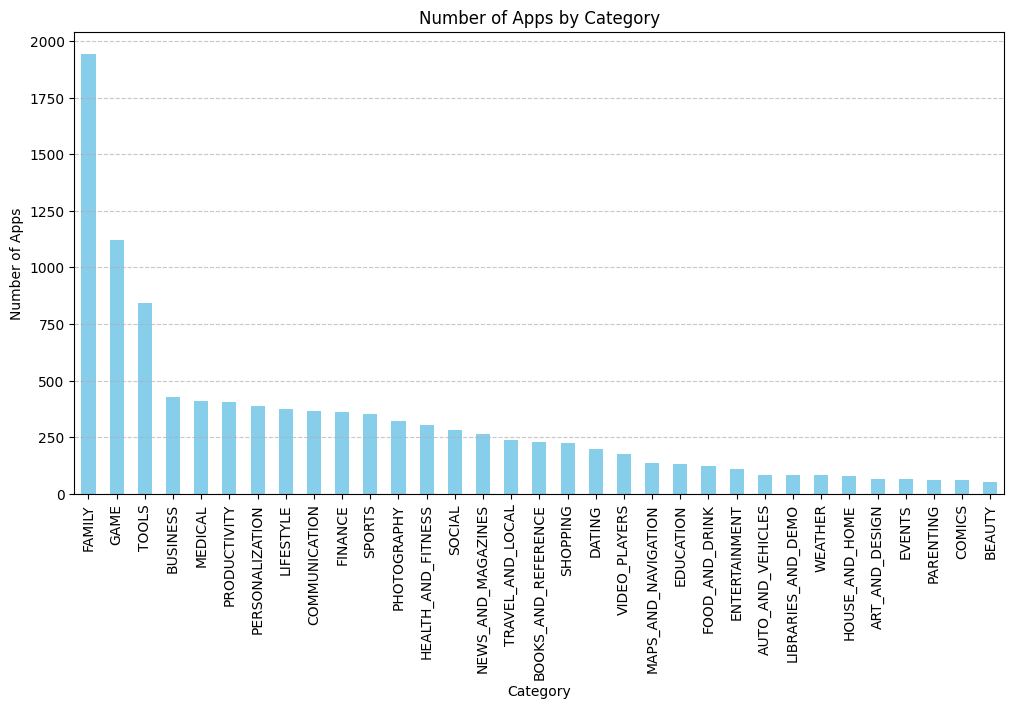

In [21]:
category_counts = df["Category"].value_counts()

print(category_counts)

plt.figure(figsize=(12,6))

category_counts.plot(kind="bar", color="skyblue")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 7.2 Distribution of App Ratings

The distribution of app ratings helps understand how users evaluate Android applications. It provides insights into whether most applications receive high, average, or low ratings.

count    10357.000000
mean         4.203737
std          0.485594
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64


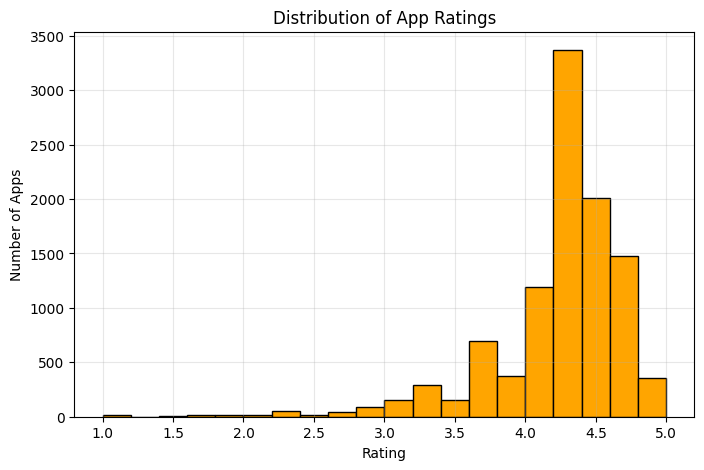

In [22]:
print(df["Rating"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=20, color="orange", edgecolor="black")

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.grid(alpha=0.3)

plt.show()

### 7.3 Top 10 Categories by Average Rating

This analysis identifies the app categories with the highest average user ratings. It helps understand which categories consistently deliver high-quality applications and better user satisfaction.

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
Name: Rating, dtype: float64


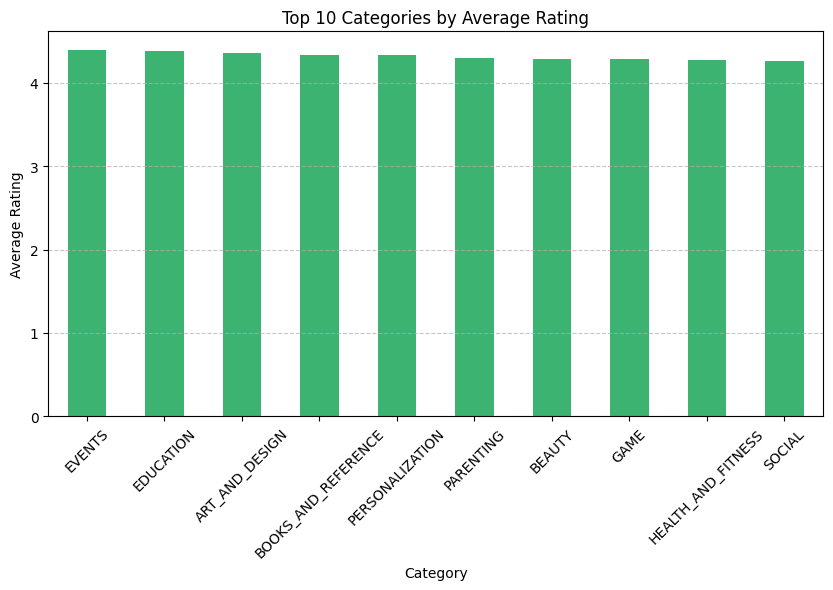

In [23]:
top_rating = (
    df.groupby("Category")["Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_rating)

plt.figure(figsize=(10,5))

top_rating.plot(kind="bar", color="mediumseagreen")

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 7.4 Top 10 Categories by Total Installs

This analysis examines the categories with the highest total number of installs. It helps identify the most popular application categories among Android users.

Category
GAME                  31544024415
COMMUNICATION         24152276251
SOCIAL                12513867902
PRODUCTIVITY          12463091369
TOOLS                 11452771915
FAMILY                10041692505
PHOTOGRAPHY            9721247655
TRAVEL_AND_LOCAL       6361887146
VIDEO_PLAYERS          6222002720
NEWS_AND_MAGAZINES     5393217760
Name: Installs, dtype: int64


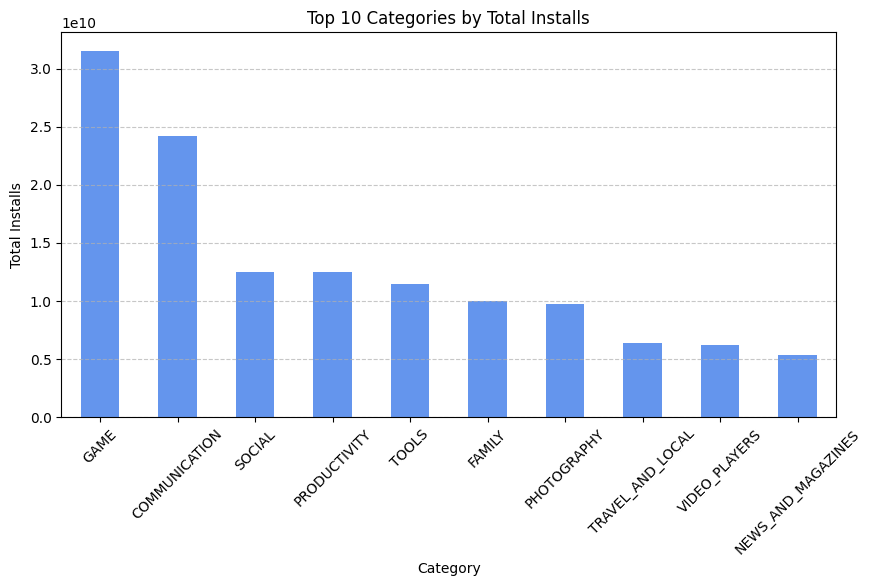

In [24]:
top_installs = (
    df.groupby("Category")["Installs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_installs)

plt.figure(figsize=(10,5))

top_installs.plot(kind="bar", color="cornflowerblue")

plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 7.5 Free vs Paid Applications

This analysis compares the number of free and paid applications available on the Google Play Store. It helps understand the distribution of monetization models adopted by app developers.

Type
Free    9592
Paid     765
Name: count, dtype: int64


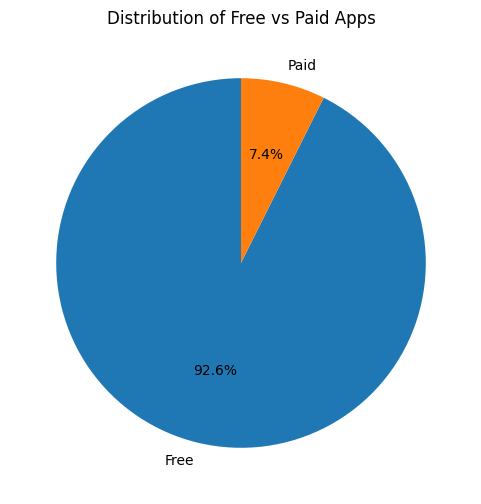

In [25]:
app_type = df["Type"].value_counts()

print(app_type)

plt.figure(figsize=(6,6))

plt.pie(
    app_type,
    labels=app_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Free vs Paid Apps")

plt.show()

### 7.6 Price Distribution of Paid Applications

This analysis examines the pricing pattern of paid applications available on the Google Play Store. Since free applications have a price of zero, only paid applications are considered to better understand pricing trends.

count    742.000000
mean       4.449070
std        5.442888
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max       46.990000
Name: Price, dtype: float64


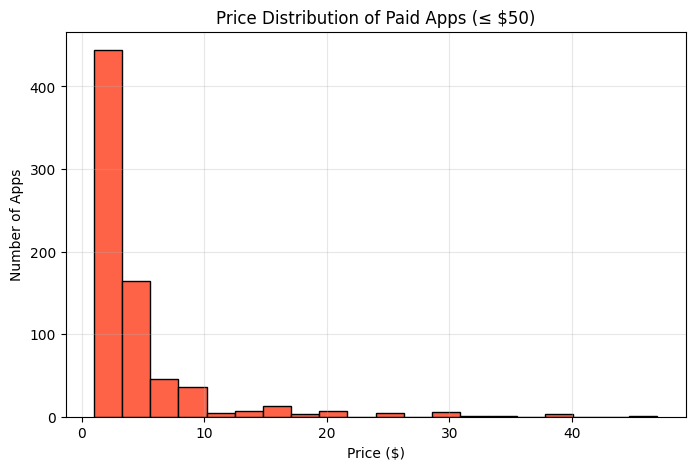

In [27]:
paid_apps = df[df["Type"] == "Paid"]

# Remove extreme prices only for plotting
price_plot = paid_apps[paid_apps["Price"] <= 50]

print(price_plot["Price"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    price_plot["Price"],
    bins=20,
    color="tomato",
    edgecolor="black"
)

plt.title("Price Distribution of Paid Apps (≤ $50)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.grid(alpha=0.3)

plt.show()

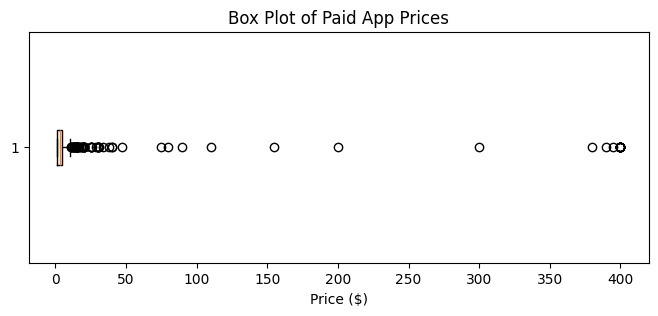

In [28]:
plt.figure(figsize=(8,3))

plt.boxplot(paid_apps["Price"], vert=False)

plt.title("Box Plot of Paid App Prices")
plt.xlabel("Price ($)")

plt.show()

### 7.7 Relationship Between Reviews and Ratings

This analysis explores the relationship between the number of user reviews and app ratings. The scatter plot helps determine whether applications with more reviews tend to receive higher ratings.

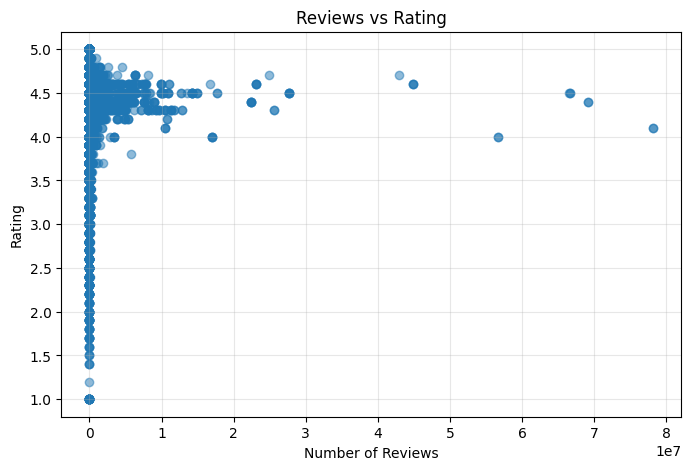

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Reviews"],
    df["Rating"],
    alpha=0.5
)

plt.title("Reviews vs Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.grid(alpha=0.3)

plt.show()

### 7.8 Correlation Analysis

Correlation analysis measures the strength of relationships between numerical variables in the dataset. A heatmap is used to visualize these relationships and identify positive or negative correlations among features.

            Rating   Reviews      Size  Installs     Price
Rating    1.000000  0.063465  0.052706  0.044829 -0.019709
Reviews   0.063465  1.000000  0.107819  0.634997 -0.009417
Size      0.052706  0.107819  1.000000  0.050121 -0.020537
Installs  0.044829  0.634997  0.050121  1.000000 -0.011147
Price    -0.019709 -0.009417 -0.020537 -0.011147  1.000000


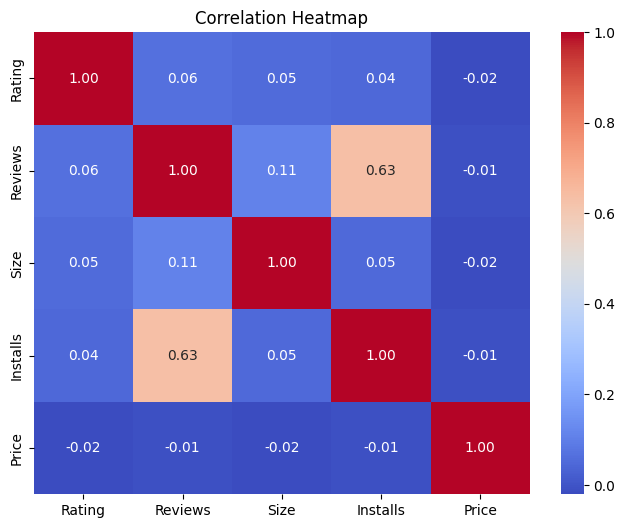

In [30]:
correlation = df[["Rating","Reviews","Size","Installs","Price"]].corr()

print(correlation)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### 7.9 Top 10 Most Reviewed Applications

This analysis identifies the applications with the highest number of user reviews on the Google Play Store. A higher number of reviews generally indicates greater user engagement and popularity.

                                           App   Reviews
2544                                  Facebook  78158306
3943                                  Facebook  78128208
336                         WhatsApp Messenger  69119316
3904                        WhatsApp Messenger  69109672
2604                                 Instagram  66577446
2545                                 Instagram  66577313
3909                                 Instagram  66509917
382   Messenger – Text and Video Chat for Free  56646578
335   Messenger – Text and Video Chat for Free  56642847
1879                            Clash of Clans  44893888


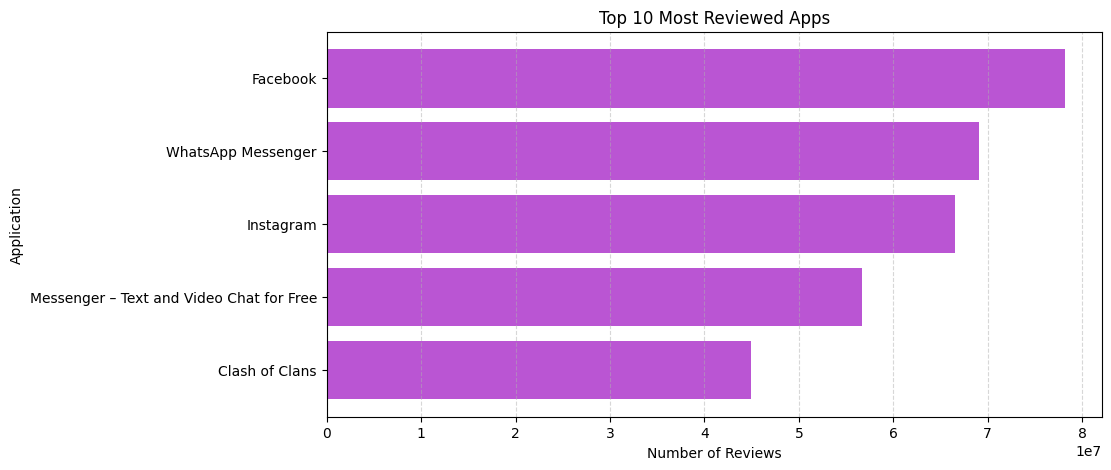

In [31]:
top_reviews = (
    df[["App", "Reviews"]]
    .sort_values(by="Reviews", ascending=False)
    .head(10)
)

print(top_reviews)

plt.figure(figsize=(10,5))

plt.barh(top_reviews["App"], top_reviews["Reviews"], color="mediumorchid")

plt.title("Top 10 Most Reviewed Apps")
plt.xlabel("Number of Reviews")
plt.ylabel("Application")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### 7.10 Top 10 Most Installed Applications

This analysis identifies the applications with the highest number of installs on the Google Play Store. These applications represent the most widely adopted apps among Android users.

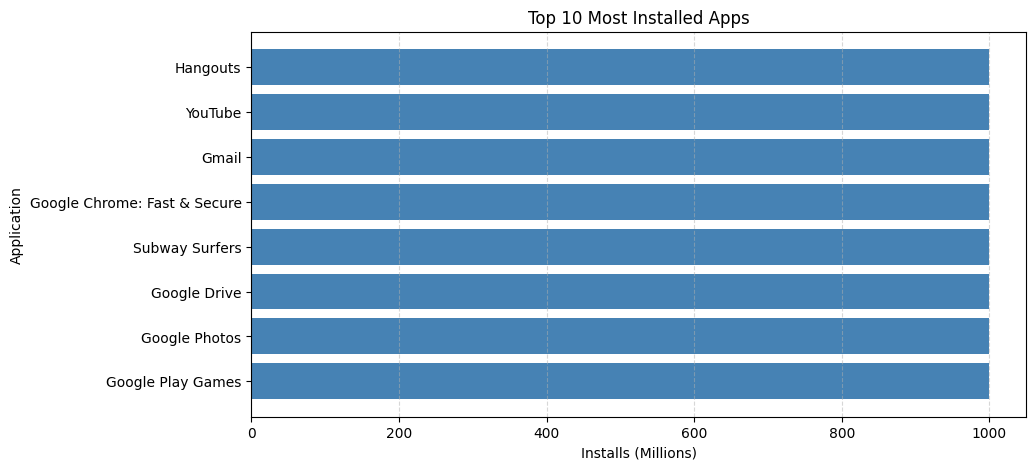

In [33]:
top_installed_apps = (
    df[["App", "Installs"]]
    .sort_values(by="Installs", ascending=False)
    .head(10)
)

# Convert installs to millions for visualization
top_installed_apps["Installs (Millions)"] = top_installed_apps["Installs"] / 1_000_000

plt.figure(figsize=(10,5))

plt.barh(
    top_installed_apps["App"],
    top_installed_apps["Installs (Millions)"],
    color="steelblue"
)

plt.title("Top 10 Most Installed Apps")
plt.xlabel("Installs (Millions)")
plt.ylabel("Application")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### 7.9 Average Installs by Category

This analysis calculates the average number of installs for each app category. It helps identify categories that consistently achieve higher user adoption, regardless of the number of applications available.

Category
COMMUNICATION         6.598983e+07
SOCIAL                4.469239e+07
VIDEO_PLAYERS         3.555430e+07
PRODUCTIVITY          3.062185e+07
PHOTOGRAPHY           3.019021e+07
GAME                  2.813918e+07
TRAVEL_AND_LOCAL      2.684341e+07
ENTERTAINMENT         2.212306e+07
NEWS_AND_MAGAZINES    2.042886e+07
TOOLS                 1.358573e+07
Name: Installs, dtype: float64


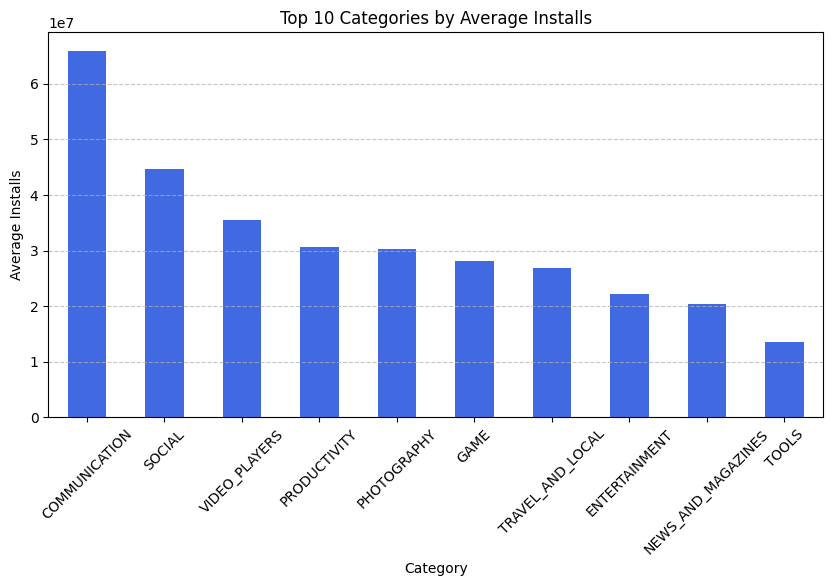

In [34]:
avg_installs = (
    df.groupby("Category")["Installs"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(avg_installs)

plt.figure(figsize=(10,5))

avg_installs.plot(kind="bar", color="royalblue")

plt.title("Top 10 Categories by Average Installs")
plt.xlabel("Category")
plt.ylabel("Average Installs")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 7.10 Average Rating by Content Rating

This analysis compares the average ratings of applications across different content rating categories. It helps understand whether applications targeted at specific audiences receive better user feedback.

Content Rating
Adults only 18+    4.300000
Everyone 10+       4.256233
Teen               4.245462
Unrated            4.200000
Everyone           4.199117
Mature 17+         4.138479
Name: Rating, dtype: float64


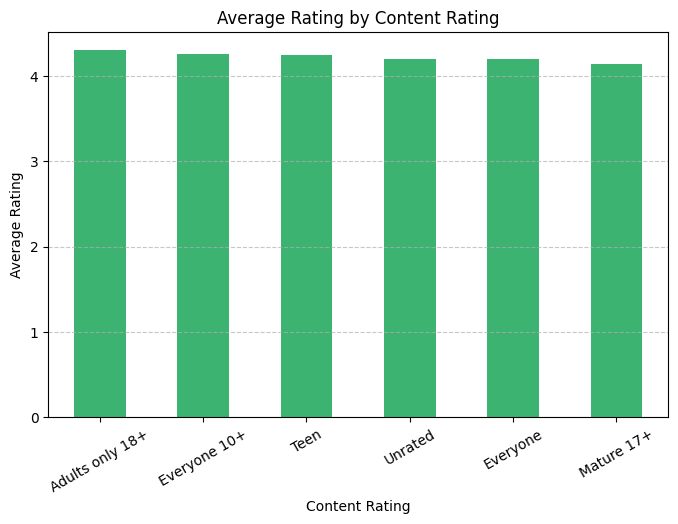

In [35]:
content_rating = (
    df.groupby("Content Rating")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

print(content_rating)

plt.figure(figsize=(8,5))

content_rating.plot(kind="bar", color="mediumseagreen")

plt.title("Average Rating by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Average Rating")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### 7.11 Free and Paid Applications Across Categories

This analysis compares the number of free and paid applications available within each app category. It provides insights into how different categories adopt monetization strategies on the Google Play Store.

Type                 Free  Paid
Category                       
ART_AND_DESIGN         62     3
AUTO_AND_VEHICLES      82     3
BEAUTY                 53     0
BOOKS_AND_REFERENCE   202    28
BUSINESS              415    12


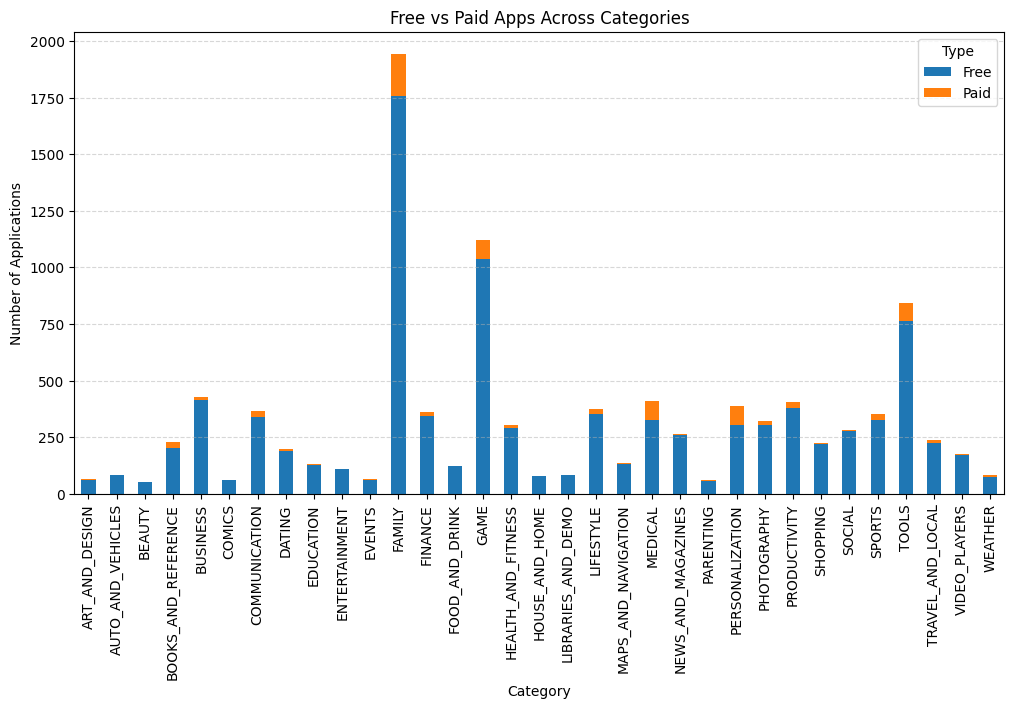

In [37]:
type_category = pd.crosstab(df["Category"], df["Type"])

print(type_category.head())

type_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Free vs Paid Apps Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Applications")

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 8. Summary Statistics

The following statistical summary provides an overview of the numerical features in the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

In [36]:
summary = df[["Rating", "Reviews", "Size", "Installs", "Price"]].describe()

print(summary)

             Rating       Reviews          Size      Installs         Price
count  10357.000000  1.035700e+04  10357.000000  1.035700e+04  10357.000000
mean       4.203737  4.059046e+05     20.066346  1.415776e+07      1.030800
std        0.485594  2.696778e+06     21.019993  8.023955e+07     16.278625
min        1.000000  0.000000e+00      0.008301  0.000000e+00      0.000000
25%        4.100000  3.200000e+01      5.700000  1.000000e+03      0.000000
50%        4.300000  1.680000e+03     13.000000  1.000000e+05      0.000000
75%        4.500000  4.641600e+04     26.000000  1.000000e+06      0.000000
max        5.000000  7.815831e+07    100.000000  1.000000e+09    400.000000


## 9. Key Findings

Based on the exploratory data analysis of the Google Play Store dataset, the following key findings were observed:

- The Google Play Store contains applications from a wide variety of categories, with some categories having significantly more applications than others.
- Most applications have ratings between **4.0 and 4.5**, indicating generally positive user feedback.
- Communication, Social, and Video Players categories recorded the highest average number of installs, highlighting their popularity among Android users.
- Free applications dominate the Google Play Store, while paid applications represent only a small percentage of the total apps.
- Most paid applications are priced below **$50**, although a few premium applications act as outliers with significantly higher prices.
- Applications with a larger number of reviews generally tend to have higher install counts, indicating greater popularity.
- The average application rating across all content rating categories remains above **4.0**, suggesting consistent user satisfaction.
- Correlation analysis indicates a positive relationship between installs and reviews, while price has little correlation with app ratings.

## 10. Business Recommendations

Based on the analysis, the following recommendations can help developers and businesses improve application performance and user engagement:

- Focus on high-demand categories such as Communication, Social, and Productivity, where user adoption is highest.
- Prioritize application quality and user experience to maintain ratings above 4.0.
- Encourage user reviews and feedback, as applications with higher engagement generally attract more downloads.
- Consider a free or freemium business model, as free applications dominate the Google Play Store.
- Keep application pricing competitive since most paid applications are priced within an affordable range.
- Regularly update applications to improve stability, security, and user satisfaction.
- Monitor user feedback continuously to identify improvement opportunities and maintain positive ratings.

## 11. Conclusion

This project explored the Google Play Store dataset using Exploratory Data Analysis (EDA) techniques to understand application trends, user behavior, pricing strategies, and market dynamics.

The analysis revealed that application popularity is strongly associated with installs, reviews, and category type, while user ratings remain consistently high across most applications. Free applications dominate the marketplace, and only a small percentage of applications follow a paid pricing model.

The insights obtained from this analysis can help developers, businesses, and market analysts make informed decisions regarding application development, pricing strategies, and user engagement. Overall, the project demonstrates the importance of data-driven decision-making in understanding the Android application market.